# TME 분석
: 종양 안에 어떤 세포들이 얼마나 있는지 구성 비율을 분석하는 것

In [1]:
import scanpy as sc

mac = sc.read_h5ad('../phase1_scrna/dataset/GSE127465_mac_phase2a.h5ad')
print(mac.obs['tam_subtype'].value_counts())

tam_subtype
Unknown      5447
SPP1+ TAM    2236
C1QC+ TAM    1423
Name: count, dtype: int64


In [2]:
print(mac)
print(mac.obs['tam_subtype'].value_counts())

AnnData object with n_obs × n_vars = 9106 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_counts', 'sample', 'leiden', 'cell_type', 'tam_subtype'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'deg_tam', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'tam_subtype_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
tam_subtype
Unknown      5447
SPP1+ TAM    2236
C1QC+ TAM    1423
Name: count, dtyp

C:\Users\82108\AppData\Local\Temp\ipykernel_17112\3653213515.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['sample', 'tam_subtype'])


tam_subtype  C1QC+ TAM  SPP1+ TAM  Unknown
sample                                    
0                 15.9       30.7     53.4
1                 16.1       30.5     53.4
2                 18.9       31.6     49.5
3                 15.8       34.8     49.4
4                  0.0        0.0    100.0
5                  0.0        0.3     99.7
6                  0.0        1.9     98.1
7                  6.2       21.9     71.9
8                  7.7       34.6     57.7
9                  0.0        0.0    100.0
10                13.8       19.7     66.6
11                17.0       19.8     63.3
12                15.3       18.9     65.8
13                 0.0        0.0    100.0
14                21.4       26.6     51.9
15                17.4       26.3     56.3
16                20.3       24.1     55.7
17                 0.0        0.0    100.0
18                19.3       33.9     46.8
19                21.9       30.2     48.0
20                20.6       26.4     53.0
21         

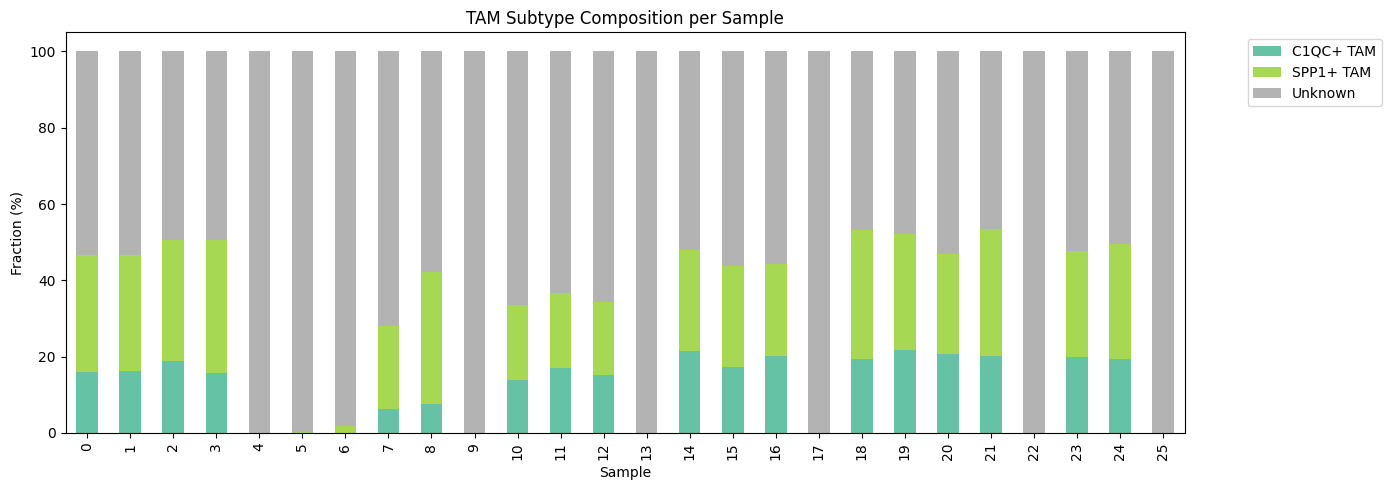

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 샘플별 TAM 서브타입 비율 계산
composition = (
    mac.obs
    .groupby(['sample', 'tam_subtype'])
    .size()
    .unstack(fill_value=0)
)

# 비율로 변환
composition_pct = composition.div(composition.sum(axis=1), axis=0) * 100
print(composition_pct.round(1))

# stacked bar plot
composition_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 5),
    colormap='Set2'
)
plt.title('TAM Subtype Composition per Sample')
plt.ylabel('Fraction (%)')
plt.xlabel('Sample')
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [5]:
# h5ad 저장
mac.write('../phase1_scrna/dataset/GSE127465_mac_phase2a_tme.h5ad')